In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import torchvision
from tqdm import tqdm
import sys
from pathlib import Path
import open_clip
import torchvision.transforms.functional as F

In [2]:
sys.path.append(str(Path().resolve().parent))
str(Path().resolve().parent)

'/Users/mohamedmafaz/Desktop/img2img_DiT'

In [3]:
from DiT_model import DiT
from data import img_dataset
from VAE import VAE
from DDPM import LinearNoiseScheduler

In [4]:
dataset = img_dataset(root_dir = "../buildings", img_size = 224)
dataloader = DataLoader(dataset, batch_size = 1, shuffle = True)

In [5]:
import json
with open("../config/config.json", "r") as file:
    config = json.load(file)

device = "cpu"

In [6]:
vae = VAE(device = device, freeze = True, scaling_factor = config["VAE"]["scaling_factor"], path = "../pretrained/sd-vae-ft-mse").to(device)

dit = DiT(d_model           = config["DiT"]["d_model"],
          g_channels        = config["DiT"]["g_channels"],
          grid_size         = config["DiT"]["grid_size"],
          patch_size        = config["DiT"]["patch_size"],
          timestep_emb_dim  = config["DiT"]["timestep_emb_dim"],
          number_emb_dim    = config["DiT"]["number_emb_dim"],
          num_layers        = config["DiT"]["num_layers"],
          num_heads         = config["DiT"]["num_heads"],
          CLIP_dim          = config["DiT"]["CLIP_dim"])

scheduler = LinearNoiseScheduler(num_timesteps  = config["Scheduler"]["num_timesteps"],
                                     beta_start = config["Scheduler"]["beta_start"],
                                     beta_end   = config["Scheduler"]["beta_end"])

clip_model = open_clip.create_model(
    "ViT-L-14",
    pretrained="../pretrained/models--timm--vit_large_patch14_clip_224.openai/snapshots/18d0535469bb561bf468d76c1d73aa35156c922b/open_clip_model.safetensors"
)

In [7]:
dit.load_state_dict(torch.load("../img2img_DiT_buildings.pth", map_location = device))

dit.eval()
clip_model.eval()

CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14), bias=False)
    (patch_dropout): Identity()
    (ln_pre): LayerNorm((1024,), eps=1e-05, elementwise_affine=True, bias=True)
    (transformer): Transformer(
      (resblocks): ModuleList(
        (0-23): 24 x ResidualAttentionBlock(
          (ln_1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True, bias=True)
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=1024, out_features=1024, bias=True)
          )
          (ls_1): Identity()
          (ln_2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True, bias=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=1024, out_features=4096, bias=True)
            (gelu): GELU(approximate='none')
            (c_proj): Linear(in_features=4096, out_features=1024, bias=True)
          )
          (ls_2): Identity()
        )
      )
    )
    (ln_post): LayerN

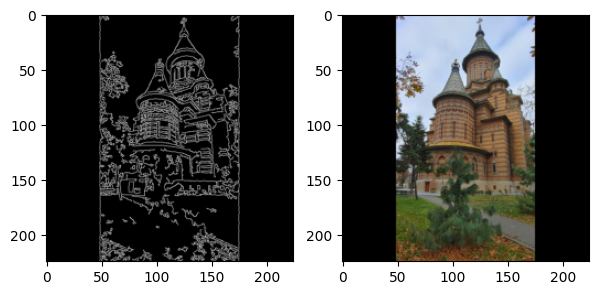

In [31]:
for condition_image, actual_image in dataloader:
    break

fig, axs = plt.subplots(1, 2, figsize = (7, 12))
axs[0].imshow((condition_image[0].permute(1,2,0).detach().cpu().numpy()+1)/2)
axs[1].imshow((actual_image[0].permute(1,2,0).detach().cpu().numpy()+1)/2)

plt.show()

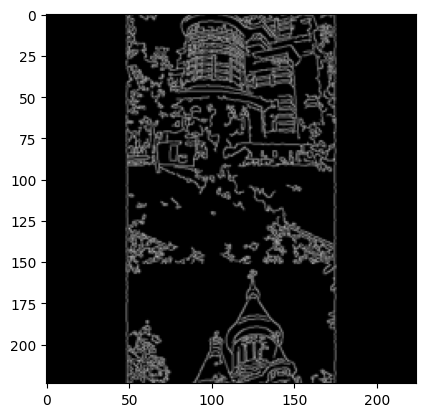

In [32]:
temp_torch = torch.roll(condition_image, shifts = 600, dims=2)
plt.imshow((temp_torch[0].permute(1,2,0).detach().cpu().numpy()+1)/2)

In [33]:
CLIP_MEAN = torch.tensor([0.48145466, 0.4578275, 0.40821073], device=device).view(1,3,1,1)
CLIP_STD  = torch.tensor([0.26862954, 0.26130258, 0.27577711], device=device).view(1,3,1,1)

def clip_preproces(img):
    # images are normalised [-1, 1] for VAE and DiT
    img = (img + 1)/2
    if (img.shape[-1] != 224) or (img.shape[-2] != 224):
        img = torch.nn.functional.interpolate(img, size=224, mode='bicubic', align_corners=False)
    img = (img - CLIP_MEAN) / CLIP_STD
    return img

@torch.no_grad()
def sample(latent_grid_size: int, dit, vae, device, scheduler, condition_image):
    xt = torch.randn((1, 4, latent_grid_size, latent_grid_size)).to(device)

    # condition image VAE-ing
    with torch.no_grad():
        mu_c, logvar_c = vae.encode(condition_image)
        z_c = vae.reparameterize(mu_c, logvar_c) 

    clip_condition = clip_model.encode_image(clip_preproces(condition_image)) # [B, 768]

    for i in tqdm(reversed(range(1000))):
        noise_pred = dit(xt, 
                       torch.as_tensor(i).unsqueeze(0).to(device), 
                       z_c, 
                       clip_condition)
        
        xt, x0_pred = scheduler.sample_prev_timestep(xt, noise_pred, torch.as_tensor(i).to(device))

    img_tensor = vae.decode(xt)
    img_tensor = torch.clamp(img_tensor, -1., 1.).detach().cpu()
    img_tensor = (img_tensor + 1) / 2
    img = torchvision.transforms.ToPILImage()(img_tensor[0])
    return img

1000it [00:45, 22.03it/s]


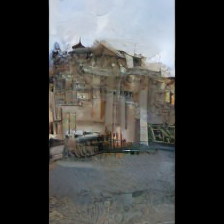

In [34]:
# img = sample(28, dit, vae, device, scheduler, condition_image)
img = sample(28, dit, vae, device, scheduler, temp_torch)
img

1000it [00:42, 23.41it/s]


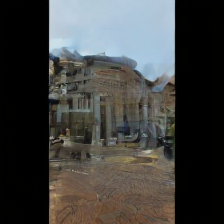

In [14]:
img = sample(28, dit, vae, device, scheduler, condition_image)
img

In [ ]:
import gradio as gr
import numpy as np
from PIL import Image

WIDTH = 512
HEIGHT = 512

# Black canvas
canvas = Image.new("RGB", (WIDTH, HEIGHT), (0, 0, 0))

with gr.Blocks() as demo:
    sketch = gr.ImageEditor(
        value=canvas,
        image_mode="RGB",
        type="pil",
        layers=False,
        canvas_size=(WIDTH, HEIGHT),
        brush=gr.Brush(
            colors=["#FFFFFF"],      # White brush
            default_color="#FFFFFF",
            color_mode="fixed",
            default_size=2,          # Thin line
        ),
    )

    out = gr.Image()

    def submit(img):
        img = torch.from_numpy(np.array(img['composite'])).float() / 255.0  
        
        img = img.permute(-1, 0, 1)#.unsqueeze(0)
        img = F.resize(img, (224, 224))
        img = img.unsqueeze(0)

        img = sample(28, dit, vae, device, scheduler, img)

        return img

    gr.Button("Submit").click(submit, sketch, out)

demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


1000it [00:54, 18.32it/s]
1000it [00:49, 20.29it/s]
1000it [00:44, 22.71it/s]


In [ ]:
gray = img.convert("L")
arr = np.array(gray)
arr = np.where(arr > 127, 255, 0).astype(np.uint8)
img = Image.fromarray(arr).convert("RGB")

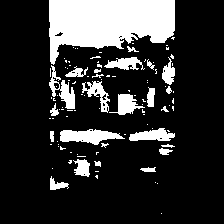

In [ ]:
img